Plot code cells for the most recent (and hopefully final) results.
Each cell explains which plot it shows and why (easier than trying to remember from memory every time)

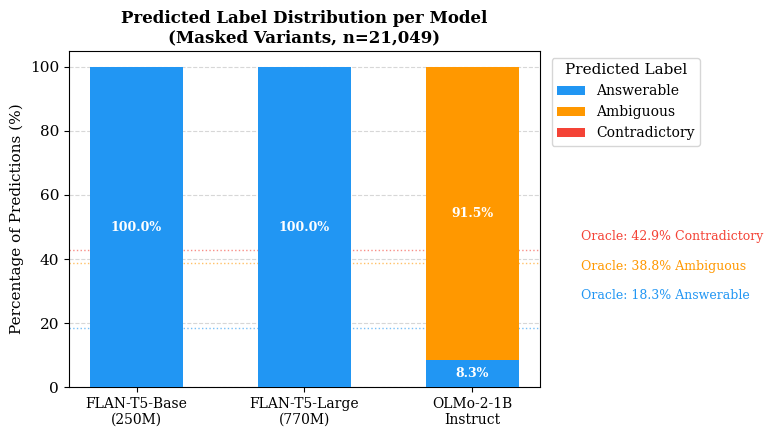

Saved: ../reports/plots2/predicted_label_distribution_by_model.pdf


In [15]:
# =============================================================================
# Plot 1: Predicted label distribution across models (masked variants)
# 
# What it shows:
#   Side-by-side stacked bars showing what each model actually predicted
#   across all 21,049 masked variant samples.
#
# Why it exists:
#   Visually demonstrates the core finding — FLAN-T5 collapses to Answerable,
#   OLMo collapses to Ambiguous, no model meaningfully predicts Contradictory.
#   Makes the degenerate prediction behavior immediately obvious without
#   requiring the reader to parse a confusion matrix.
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import os

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11

SAVE_DIR = "../reports/plots2"
os.makedirs(SAVE_DIR, exist_ok=True)

LABEL_COLORS = {
    'Answerable':    '#2196F3',
    'Ambiguous':     '#FF9800',
    'Contradictory': '#F44336',
    'UNPARSEABLE':   '#9E9E9E',
}
LABELS = ['Answerable', 'Ambiguous', 'Contradictory']

# Load results
base   = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_BASE.parquet")
large  = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_LARGE.parquet")
olmo   = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_OLMO.parquet")

models = {
    'FLAN-T5-Base\n(250M)':  base,
    'FLAN-T5-Large\n(770M)': large,
    'OLMo-2-1B\nInstruct':   olmo,
}

total = len(base)

fig, ax = plt.subplots(figsize=(8, 4.5))

x = range(len(models))
bar_width = 0.55
bottoms = [0] * len(models)

for label in LABELS:
    counts = [
        (df['predicted_label'] == label).sum() / total * 100
        for df in models.values()
    ]
    bars = ax.bar(x, counts, bar_width, bottom=bottoms,
                  color=LABEL_COLORS[label], label=label, zorder=3)
    # Annotate segments > 5%
    for i, (count, bottom) in enumerate(zip(counts, bottoms)):
        if count > 5:
            ax.text(i, bottom + count / 2, f'{count:.1f}%',
                    ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
    bottoms = [b + c for b, c in zip(bottoms, counts)]

ax.set_xticks(list(x))
ax.set_xticklabels(list(models.keys()), fontsize=10)
ax.set_ylabel('Percentage of Predictions (%)', fontsize=11)
ax.set_title('Predicted Label Distribution per Model\n(Masked Variants, n=21,049)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(title='Predicted Label', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=10)

# Add oracle distribution reference line annotations
ax.axhline(y=42.9, color='#F44336', linestyle=':', linewidth=1, alpha=0.6)
ax.axhline(y=38.8, color='#FF9800', linestyle=':', linewidth=1, alpha=0.6)
ax.axhline(y=18.3, color='#2196F3', linestyle=':', linewidth=1, alpha=0.6)
ax.text(2.65, 46.0, 'Oracle: 42.9% Contradictory', fontsize=9,
        color='#F44336', alpha=1.0)
ax.text(2.65, 36.5, 'Oracle: 38.8% Ambiguous', fontsize=9,
        color='#FF9800', alpha=1.0)
ax.text(2.65, 27.5, 'Oracle: 18.3% Answerable', fontsize=9,
        color='#2196F3', alpha=1.0)

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, "predicted_label_distribution_by_model.pdf")
plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

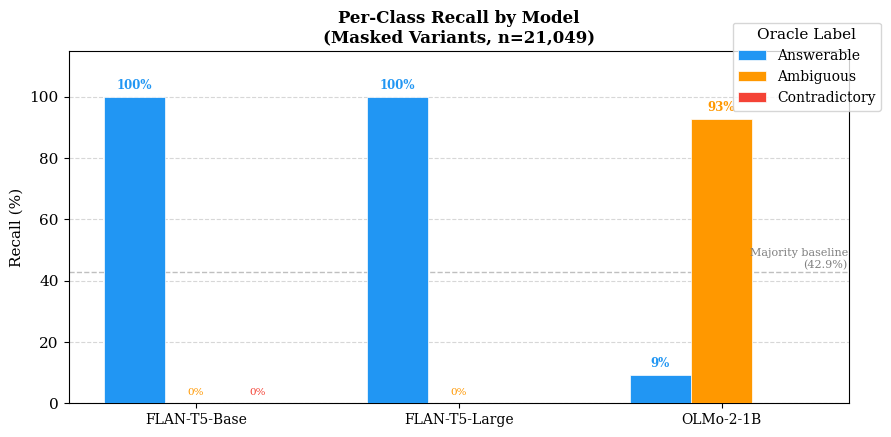

Saved: ../reports/plots2/per_class_recall_by_model.pdf


In [8]:
# =============================================================================
# Plot 2: Per-class recall across models (masked variants)
#
# What it shows:
#   Grouped bar chart showing recall for each oracle label class
#   (Answerable, Ambiguous, Contradictory) per model.
#
# Why it exists:
#   Overall accuracy is misleading due to label imbalance. This plot shows
#   that FLAN-T5's accuracy comes entirely from Answerable recall=100%,
#   and OLMo's from Ambiguous recall=92.8%. No model has meaningful
#   Contradictory recall. Directly supports the "fixed prior" finding.
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11

SAVE_DIR = "../reports/plots2"
os.makedirs(SAVE_DIR, exist_ok=True)

base  = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_BASE.parquet")
large = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_LARGE.parquet")
olmo  = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_OLMO.parquet")

models = {
    'FLAN-T5-Base':  base,
    'FLAN-T5-Large': large,
    'OLMo-2-1B':     olmo,
}

LABELS = ['Answerable', 'Ambiguous', 'Contradictory']
LABEL_COLORS = {
    'Answerable':    '#2196F3',
    'Ambiguous':     '#FF9800',
    'Contradictory': '#F44336',
}

def recall(df, label):
    subset = df[df['oracle_label'] == label]
    if len(subset) == 0:
        return 0.0
    return (subset['predicted_label'] == label).mean() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))

n_models = len(models)
n_labels = len(LABELS)
group_width = 0.7
bar_width = group_width / n_labels
x = np.arange(n_models)

for i, label in enumerate(LABELS):
    recalls = [recall(df, label) for df in models.values()]
    offset = (i - n_labels / 2 + 0.5) * bar_width
    bars = ax.bar(x + offset, recalls, bar_width,
                  color=LABEL_COLORS[label], label=label,
                  zorder=3, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, recalls):
        label_val = f'{val:.0f}%'
        if val > 3:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5,
                    f'{val:.0f}%', ha='center', va='bottom',
                    fontsize=8.5, fontweight='bold',
                    color=LABEL_COLORS[label])
        elif val == 0:
            ax.text(bar.get_x() + bar.get_width() / 2, 2.0,
                    '0%', ha='center', va='bottom', fontsize=7.5, color=LABEL_COLORS[label])

ax.set_xticks(x)
ax.set_xticklabels(list(models.keys()), fontsize=10)
ax.set_ylabel('Recall (%)', fontsize=11)
ax.set_title('Per-Class Recall by Model\n(Masked Variants, n=21,049)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 115)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(title='Oracle Label', fontsize=10, bbox_to_anchor=(1.05, 1.10), loc='upper right')

# Majority baseline annotation
ax.axhline(y=42.9, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.text(2.48, 44, 'Majority baseline\n(42.9%)', fontsize=8,
        color='gray', ha='right')

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, "per_class_recall_by_model.pdf")
plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

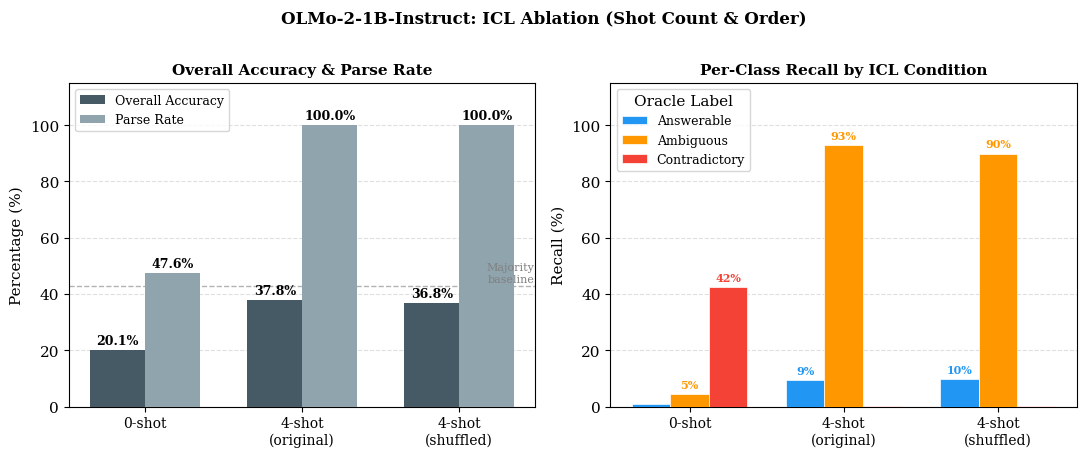

Saved: ../reports/plots2/icl_ablation_olmo.pdf


In [ ]:
# =============================================================================
# Plot 3: ICL shot count and order ablation (OLMo-2-1B-Instruct)
#
# What it shows:
#   Three conditions for OLMo: 0-shot, 4-shot original order, 4-shot shuffled.
#   Shows overall accuracy, parse rate, and per-class recall side by side.
#
# Why it exists:
#   Directly addresses the project guidelines requirement to account for
#   prompt sensitivity and randomness. Shows that demonstrations are necessary
#   (0-shot fails) and that example order does not matter (shuffled ≈ original).
#   Scientifically validates the 4-shot setup as robust.
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11

SAVE_DIR = "../reports/plots2"
os.makedirs(SAVE_DIR, exist_ok=True)

zeroshot = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_ZEROSHOT.parquet")
fourshot = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_OLMO.parquet")
shuffled = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_SHUF.parquet")

conditions = {
    '0-shot':           zeroshot,
    '4-shot\n(original)': fourshot,
    '4-shot\n(shuffled)': shuffled,
}

LABELS = ['Answerable', 'Ambiguous', 'Contradictory']
LABEL_COLORS = {
    'Answerable':    '#2196F3',
    'Ambiguous':     '#FF9800',
    'Contradictory': '#F44336',
}

def recall(df, label):
    subset = df[df['oracle_label'] == label]
    if len(subset) == 0:
        return 0.0
    return (subset['predicted_label'] == label).mean() * 100

def overall_acc(df):
    return df['is_correct'].mean() * 100

def parse_rate(df):
    return (df['predicted_label'] != 'UNPARSEABLE').mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left panel: overall accuracy and parse rate
ax1 = axes[0]
x = np.arange(len(conditions))
bar_width = 0.35

accs = [overall_acc(df) for df in conditions.values()]
parses = [parse_rate(df) for df in conditions.values()]

bars1 = ax1.bar(x - bar_width/2, accs, bar_width,
                color='#455A64', label='Overall Accuracy', zorder=3)
bars2 = ax1.bar(x + bar_width/2, parses, bar_width,
                color='#90A4AE', label='Parse Rate', zorder=3)

for bar, val in zip(bars1, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, parses):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.axhline(y=42.9, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax1.text(2.48, 44., 'Majority\nbaseline', fontsize=8, color='gray', ha='right')
ax1.set_xticks(x)
ax1.set_xticklabels(list(conditions.keys()), fontsize=10)
ax1.set_ylabel('Percentage (%)', fontsize=11)
ax1.set_title('Overall Accuracy & Parse Rate', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 115)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax1.set_axisbelow(True)
ax1.legend(fontsize=9, loc='upper left')

# Right panel: per-class recall
ax2 = axes[1]
n_cond = len(conditions)
n_labels = len(LABELS)
group_width = 0.75
bar_w = group_width / n_labels
x2 = np.arange(n_cond)

for i, label in enumerate(LABELS):
    recalls = [recall(df, label) for df in conditions.values()]
    offset = (i - n_labels/2 + 0.5) * bar_w
    bars = ax2.bar(x2 + offset, recalls, bar_w,
                   color=LABEL_COLORS[label], label=label,
                   zorder=3, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, recalls):
        if val > 4:
            ax2.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 1.5,
                     f'{val:.0f}%', ha='center', va='bottom',
                     fontsize=8, fontweight='bold',
                     color=LABEL_COLORS[label])

ax2.set_xticks(x2)
ax2.set_xticklabels(list(conditions.keys()), fontsize=10)
ax2.set_ylabel('Recall (%)', fontsize=11)
ax2.set_title('Per-Class Recall by ICL Condition', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 115)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax2.set_axisbelow(True)
ax2.legend(title='Oracle Label', fontsize=9)

fig.suptitle('OLMo-2-1B-Instruct: ICL Ablation (Shot Count & Order)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = os.path.join(SAVE_DIR, "icl_ablation_olmo.pdf")
plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

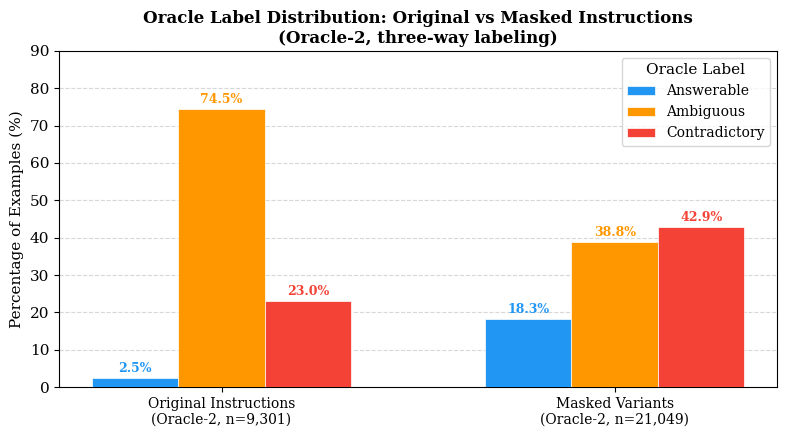

Saved: ../reports/plots2/oracle_label_distribution_original_vs_masked.pdf


In [9]:
# =============================================================================
# Plot 4: Oracle label distribution — original vs masked variants
#
# What it shows:
#   Side-by-side bar chart comparing the label distribution under Oracle-2
#   for original (unmasked) instructions vs masked variants.
#
# Why it exists:
#   Required by guidelines for dataset statistics transparency.
#   Also explains the counterintuitive finding that masking increases
#   Answerable prevalence (2.5% → 18.3%) and decreases Ambiguous prevalence
#   (74.5% → 38.8%). Without this plot, readers cannot interpret accuracy
#   differences between conditions correctly.
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11

SAVE_DIR = "../reports/plots2"
os.makedirs(SAVE_DIR, exist_ok=True)

masked   = pd.read_parquet("../reports/llm_audits/LLM_DEGRADATION_INPUT.parquet")
original = pd.read_parquet("../reports/llm_audits/ORIGINAL_ORACLE_LABELS.parquet")

LABELS = ['Answerable', 'Ambiguous', 'Contradictory']
LABEL_COLORS = {
    'Answerable':    '#2196F3',
    'Ambiguous':     '#FF9800',
    'Contradictory': '#F44336',
}

def pct(df, label, col='oracle_label'):
    return (df[col] == label).mean() * 100

conditions = {
    'Original Instructions\n(Oracle-2, n=9,301)':  original,
    'Masked Variants\n(Oracle-2, n=21,049)': masked,
}

x = np.arange(len(conditions))
bar_width = 0.22
fig, ax = plt.subplots(figsize=(8, 4.5))

for i, label in enumerate(LABELS):
    vals = [pct(df, label) for df in conditions.values()]
    offset = (i - len(LABELS)/2 + 0.5) * bar_width
    bars = ax.bar(x + offset, vals, bar_width,
                  color=LABEL_COLORS[label], label=label,
                  zorder=3, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold',
                color=LABEL_COLORS[label])

ax.set_xticks(x)
ax.set_xticklabels(list(conditions.keys()), fontsize=10)
ax.set_ylabel('Percentage of Examples (%)', fontsize=11)
ax.set_title('Oracle Label Distribution: Original vs Masked Instructions\n(Oracle-2, three-way labeling)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 90)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(title='Oracle Label', fontsize=10, loc='upper right')

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, "oracle_label_distribution_original_vs_masked.pdf")
plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

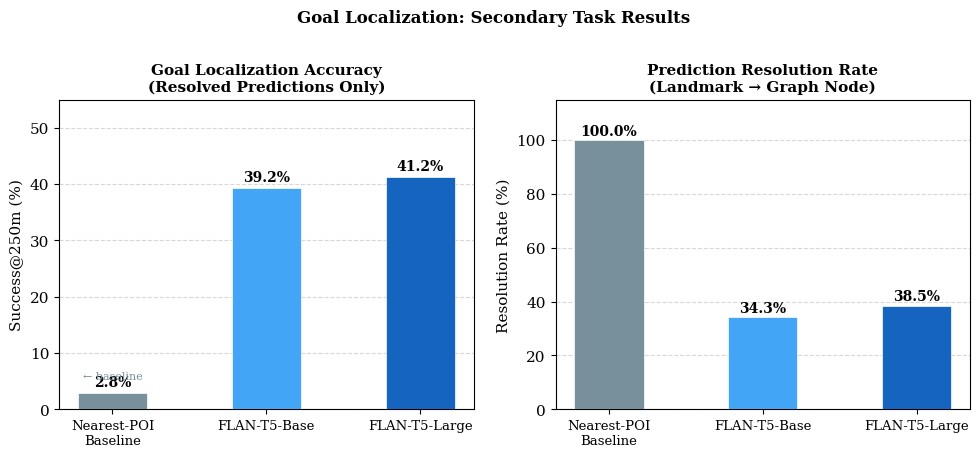

Saved: ../reports/plots2/goal_localization_results.pdf


In [7]:
# =============================================================================
# Plot 5: Goal localization — Success@250m and resolution rate by model
#
# What it shows:
#   Two-panel figure. Left: Success@250m for resolved predictions vs
#   nearest-POI baseline. Right: resolution rate (fraction of predictions
#   that mapped to a graph node) per model.
#
# Why it exists:
#   Secondary task result. Shows models substantially outperform the
#   nearest-POI baseline on Success@250m, but are severely limited by
#   low resolution rates. Both dimensions are needed to interpret the
#   localization results honestly.
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11

SAVE_DIR = "../reports/plots2"
os.makedirs(SAVE_DIR, exist_ok=True)

def load_loc(path):
    df = pd.read_parquet(path)
    df['resolution_succeeded'] = df['resolution_succeeded'].astype(str).str.lower() == 'true'
    return df

base_loc = load_loc("../reports/llm_audits/LLM_DEGRADATION_RESULTS.parquet")
large_loc = load_loc("../reports/llm_audits/LLM_DEGRADATION_RESULTS_LARGE.parquet")
poi_base  = pd.read_parquet("../reports/llm_audits/NEAREST_POI_BASELINE.parquet")

models = {
    'Nearest-POI\nBaseline': None,
    'FLAN-T5-Base':          base_loc,
    'FLAN-T5-Large':         large_loc,
}

# Success@250m (resolved only for LLM models; all for baseline)
def success_250(df, is_baseline=False):
    if is_baseline:
        return df['success_250m'].mean() * 100
    resolved = df[df['resolution_succeeded']]
    if len(resolved) == 0:
        return 0.0
    vals = resolved['success_250m']
    if vals.dtype == object:
        vals = vals.map({'True': True, 'False': False, True: True, False: False})
    return vals.mean() * 100

def res_rate(df):
    return df['resolution_succeeded'].mean() * 100

s250 = [
    success_250(poi_base, is_baseline=True),
    success_250(base_loc),
    success_250(large_loc),
]
rrates = [100.0, res_rate(base_loc), res_rate(large_loc)]

MODEL_COLORS = ['#78909C', '#42A5F5', '#1565C0']
x = np.arange(len(models))
bar_width = 0.45

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Left: Success@250m
ax1 = axes[0]
bars = ax1.bar(x, s250, bar_width, color=MODEL_COLORS, zorder=3,
               edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, s250):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(list(models.keys()), fontsize=9.5)
ax1.set_ylabel('Success@250m (%)', fontsize=11)
ax1.set_title('Goal Localization Accuracy\n(Resolved Predictions Only)',
              fontsize=11, fontweight='bold')
ax1.set_ylim(0, 55)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax1.set_axisbelow(True)
ax1.text(0, s250[0] + 2.5, '← baseline', fontsize=8, color='#78909C',
         ha='center')

# Right: Resolution rate
ax2 = axes[1]
bars2 = ax2.bar(x, rrates, bar_width, color=MODEL_COLORS, zorder=3,
                edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, rrates):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(list(models.keys()), fontsize=9.5)
ax2.set_ylabel('Resolution Rate (%)', fontsize=11)
ax2.set_title('Prediction Resolution Rate\n(Landmark → Graph Node)',
              fontsize=11, fontweight='bold')
ax2.set_ylim(0, 115)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax2.set_axisbelow(True)

fig.suptitle('Goal Localization: Secondary Task Results',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = os.path.join(SAVE_DIR, "goal_localization_results.pdf")
plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

Appendix plot code cells.

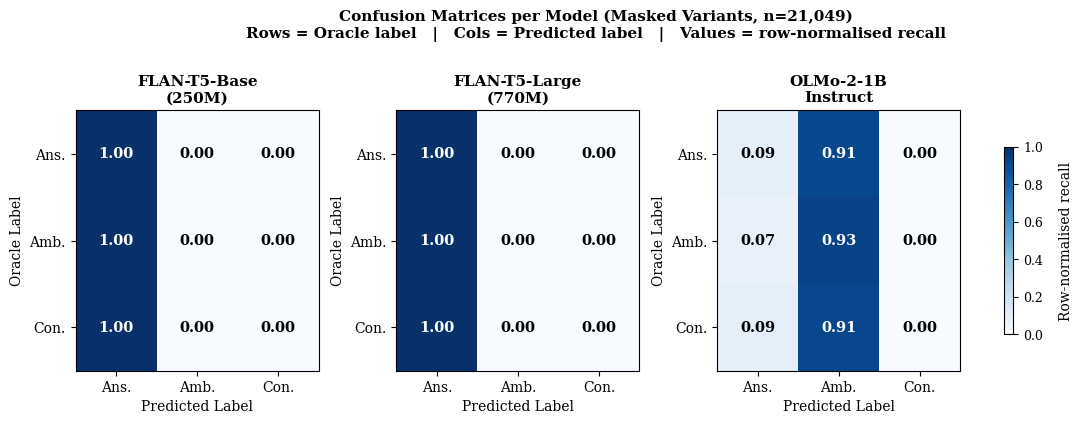

Saved: ../reports/plots2/supp_confusion_matrices.pdf


In [5]:
# =============================================================================
# Supplementary Plot A: Confusion matrices per model (masked variants)
#
# What it shows:
#   One 3×3 normalised confusion matrix per model (oracle rows × predicted cols).
#   Each cell shows row-normalised recall (i.e. per-class recall).
#
# Why it exists:
#   Complements the per-class recall bar charts with the full joint distribution.
#   Confirms that FLAN-T5 maps everything to Answerable and OLMo maps everything
#   to Ambiguous — no cross-class signal is present in either model.
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11

SAVE_DIR = "../reports/plots2"
os.makedirs(SAVE_DIR, exist_ok=True)

base  = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_BASE.parquet")
large = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_LARGE.parquet")
olmo  = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_OLMO.parquet")

models = {
    'FLAN-T5-Base\n(250M)':  base,
    'FLAN-T5-Large\n(770M)': large,
    'OLMo-2-1B\nInstruct':   olmo,
}

LABELS = ['Answerable', 'Ambiguous', 'Contradictory']
LABEL_ABBR = ['Ans.', 'Amb.', 'Con.']

def build_conf_matrix(df, labels=LABELS):
    """Row-normalised confusion matrix (oracle=rows, predicted=cols)."""
    n = len(labels)
    mat = np.zeros((n, n), dtype=float)
    label_idx = {l: i for i, l in enumerate(labels)}
    for _, row in df.iterrows():
        ol = row['oracle_label']
        pl = row['predicted_label']
        if ol in label_idx and pl in label_idx:
            mat[label_idx[ol], label_idx[pl]] += 1
    # Row-normalise
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # avoid div-by-zero
    return mat / row_sums

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

for ax, (title, df) in zip(axes, models.items()):
    mat = build_conf_matrix(df)
    im = ax.imshow(mat, vmin=0, vmax=1, cmap='Blues', aspect='auto')

    # Annotate each cell
    for i in range(3):
        for j in range(3):
            val = mat[i, j]
            text_color = 'white' if val > 0.55 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=10.5, color=text_color, fontweight='bold')

    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(LABEL_ABBR, fontsize=10)
    ax.set_yticklabels(LABEL_ABBR, fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('Oracle Label', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')

# Leaves more room on the right for the shared colorbar to not overlap with the last plot
fig.subplots_adjust(
    left=0.06,
    right=0.90,   # more room for colorbar
    top=0.78,
    bottom=0.16,
    wspace=0.32   # more horizontal spacing between subplots
)

# Shared colourbar
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    shrink=0.72,
    pad=0.04  # increased spacing from plots
)

cbar.set_label('Row-normalised recall', fontsize=10, labelpad=12)
cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    'Confusion Matrices per Model (Masked Variants, n=21,049)\n'
    'Rows = Oracle label   |   Cols = Predicted label   |   Values = row-normalised recall',
    fontsize=11, fontweight='bold', y=1.02, x=0.46
)
save_path = os.path.join(SAVE_DIR, "supp_confusion_matrices.pdf")
plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

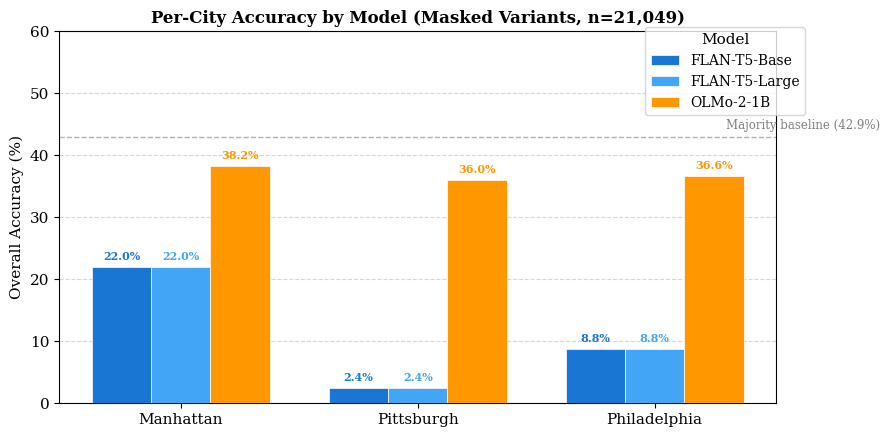

Saved: ../reports/plots2/supp_per_city_accuracy.pdf


In [12]:
# =============================================================================
# Supplementary Plot B: Per-city accuracy breakdown (masked variants)
#
# What it shows:
#   Overall accuracy per model, split by city (Manhattan, Pittsburgh,
#   Philadelphia). Presented as a grouped bar chart.
#
# Why it exists:
#   Checks whether the core findings (model collapse) generalise uniformly
#   across cities or are driven by one particular city's characteristics.
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11

SAVE_DIR = "../reports/plots2"
os.makedirs(SAVE_DIR, exist_ok=True)

base  = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_BASE.parquet")
large = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_LARGE.parquet")
olmo  = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_OLMO.parquet")

models = {
    'FLAN-T5-Base':  base,
    'FLAN-T5-Large': large,
    'OLMo-2-1B':     olmo,
}
MODEL_COLORS = ['#1976D2', '#42A5F5', '#FF9800']

# Capitalise city names for display
city_display = {
    'manhattan':    'Manhattan',
    'pittsburgh':   'Pittsburgh',
    'philadelphia': 'Philadelphia',
}
cities_ordered = ['manhattan', 'pittsburgh', 'philadelphia']

fig, ax = plt.subplots(figsize=(9, 4.5))

n_cities = len(cities_ordered)
n_models = len(models)
group_width = 0.75
bar_w = group_width / n_models
x = np.arange(n_cities)

for i, (model_name, df) in enumerate(models.items()):
    accs = []
    for city in cities_ordered:
        subset = df[df['city'] == city]
        accs.append(subset['is_correct'].mean() * 100 if len(subset) > 0 else 0.0)
    offset = (i - n_models / 2 + 0.5) * bar_w
    bars = ax.bar(x + offset, accs, bar_w,
                  color=MODEL_COLORS[i], label=model_name,
                  zorder=3, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=8, fontweight='bold', color=MODEL_COLORS[i])

ax.axhline(y=42.9, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(n_cities - 0.05, 44.2, 'Majority baseline (42.9%)',
        fontsize=8.5, color='gray', ha='right')

ax.set_xticks(x)
ax.set_xticklabels([city_display[c] for c in cities_ordered], fontsize=11)
ax.set_ylabel('Overall Accuracy (%)', fontsize=11)
ax.set_title(
    'Per-City Accuracy by Model (Masked Variants, n=21,049)',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0, 60)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(title='Model', fontsize=10, loc='upper right', bbox_to_anchor=(1.05, 1.03))

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, "supp_per_city_accuracy.pdf")
plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

In [14]:
print(masked.columns.tolist())
masked.head()

['sample_id', 'city', 'original_text', 'masked_instruction', 'variant_type', 'removed_element', 'extracted_category', 'extracted_direction', 'extracted_noun', 'start_node', 'gold_goal_node', 'gold_goal_lat', 'gold_goal_lon', 'oracle_label', 'reachable_candidate_count']


,sample_id,city,original_text,masked_instruction,variant_type,removed_element,extracted_category,extracted_direction,extracted_noun,start_node,gold_goal_node,gold_goal_lat,gold_goal_lon,oracle_label,reachable_candidate_count
0,0,manhattan,Can you meet me at the garden on Liberty Stree...,Can you meet me at the [MASK] on Liberty Stree...,mask_landmark,garden,GARDEN,N,garden,#5515156304,#697619118,40.710836,-74.013546,Ambiguous,15
1,0,manhattan,Can you meet me at the garden on Liberty Stree...,Can you meet me at the garden on Liberty Stree...,mask_directions,cardinal_directions,GARDEN,N,garden,#5515156304,#697619118,40.710836,-74.013546,Ambiguous,122
2,0,manhattan,Can you meet me at the garden on Liberty Stree...,Can you meet me at the [MASK] on Liberty Stree...,mask_both,landmarks_and_directions,GARDEN,N,garden,#5515156304,#697619118,40.710836,-74.013546,Contradictory,0
3,1,manhattan,Head northeast to meet me at the cafe on East ...,Head northeast to meet me at the [MASK] on Eas...,mask_landmark,cafe,CAFE,NE,cafe,#2709347118,#2711466517,40.753225,-73.966858,Answerable,1
4,1,manhattan,Head northeast to meet me at the cafe on East ...,Head [DIR_MASK] to meet me at the cafe on [DIR...,mask_directions,cardinal_directions,CAFE,NE,cafe,#2709347118,#2711466517,40.753225,-73.966858,Ambiguous,256


In [ ]:
# =============================================================================
# Check alignment between ORIGINAL oracle labels and masked dataset
# Ensures that sample_id keys match before any merge/join operation
# =============================================================================

import pandas as pd

# Load datasets
masked_df = pd.read_parquet("../reports/llm_audits/LLM_DEGRADATION_INPUT.parquet")
original_df = pd.read_parquet("../reports/llm_audits/ORIGINAL_ORACLE_LABELS.parquet")

# -----------------------------
# 1. Inspect columns
# -----------------------------
print("Masked DF columns:")
print(masked_df.columns.tolist())

print("\nOriginal DF columns:")
print(original_df.columns.tolist())

# -----------------------------
# 2. Verify key column exists
# -----------------------------
assert "sample_id" in masked_df.columns, "sample_id missing in masked dataset"
assert "sample_id" in original_df.columns, "sample_id missing in original dataset"

# -----------------------------
# 3. Check overlap of keys
# -----------------------------
masked_ids = set(masked_df["sample_id"])
original_ids = set(original_df["sample_id"])

common_ids = masked_ids.intersection(original_ids)

print(f"\nTotal masked samples: {len(masked_ids)}")
print(f"Total original samples: {len(original_ids)}")
print(f"Matching sample_id count: {len(common_ids)}")

# -----------------------------
# 4. Sanity checks
# -----------------------------
if len(common_ids) == 0:
    print("\nWARNING: No overlapping sample_id values found!")
else:
    print("\nSample IDs align correctly and can be safely merged.")

# -----------------------------
# 5. Preview merge
# -----------------------------
merged_preview = masked_df.merge(
    original_df[["sample_id", "oracle_label"]],
    on="sample_id",
    how="left"
)

print("\nMerged preview columns:")
print(merged_preview.columns.tolist())

print("\nExample merged rows:")
print(merged_preview.head())

Masked DF columns:
['sample_id', 'city', 'original_text', 'masked_instruction', 'variant_type', 'removed_element', 'extracted_category', 'extracted_direction', 'extracted_noun', 'start_node', 'gold_goal_node', 'gold_goal_lat', 'gold_goal_lon', 'oracle_label', 'reachable_candidate_count']

Original DF columns:
['sample_id', 'city', 'original_text', 'start_node', 'gold_goal_node', 'gold_goal_lat', 'gold_goal_lon', 'extracted_category', 'extracted_direction', 'extracted_noun', 'oracle_label_resolve', 'oracle_label', 'candidate_count', 'variant_type']

Total masked samples: 7163
Total original samples: 9301
Matching sample_id count: 7163

Sample IDs align correctly and can be safely merged.

Merged preview columns:
['sample_id', 'city', 'original_text', 'masked_instruction', 'variant_type', 'removed_element', 'extracted_category', 'extracted_direction', 'extracted_noun', 'start_node', 'gold_goal_node', 'gold_goal_lat', 'gold_goal_lon', 'oracle_label_x', 'reachable_candidate_count', 'oracle

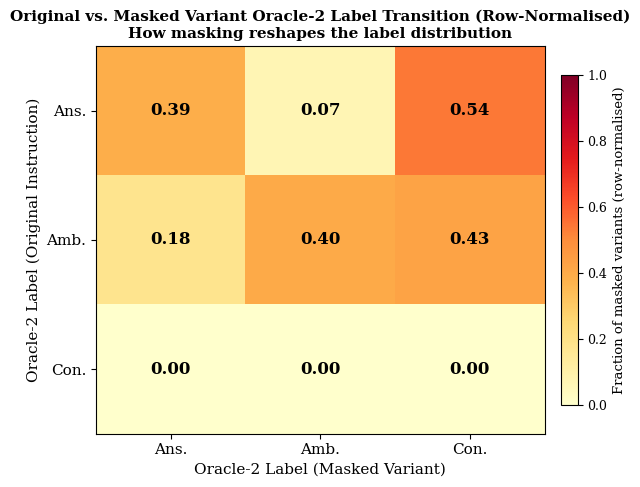

Saved: ../reports/plots2/supp_oracle_original_vs_masked_crosstab.pdf


In [15]:
# =============================================================================
# Supplementary Plot C: Oracle-1 vs. Oracle-2 label cross-tabulation
#
# What it shows:
#   A heatmap of how the Oracle-2 label on the ORIGINAL instruction maps to
#   the Oracle-2 label on each of its MASKED variants.
#
#   Each cell shows the fraction of masked variants that received a given
#   Oracle-2 label, conditioned on the original instruction's Oracle-2 label.
#   Values are row-normalised (each original-label row sums to 1.0).
#
# Why it exists:
#   Visualises how masking transforms the label space. For example:
#     - Originally Answerable examples that become Ambiguous after masking
#       (the removed landmark/direction uniquely identified the target).
#     - Originally Contradictory examples that shift to Ambiguous.
#   Mechanistically explains the label-distribution shift in core Plot 4.
#
# Data:
#   ORIGINAL_ORACLE_LABELS.parquet  — Oracle-2 labels on original instructions
#   LLM_DEGRADATION_INPUT.parquet   — Oracle-2 labels on masked variants
#   Joined on sample_id (many masked variants per original).
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11

SAVE_DIR = "../reports/plots2"
os.makedirs(SAVE_DIR, exist_ok=True)

original = pd.read_parquet("../reports/llm_audits/ORIGINAL_ORACLE_LABELS.parquet")
masked   = pd.read_parquet("../reports/llm_audits/LLM_DEGRADATION_INPUT.parquet")

# Join: each masked variant inherits the Oracle-2 label of its source instruction
# original has one row per sample_id; masked has multiple rows per sample_id
merged = masked[['sample_id', 'oracle_label']].merge(
    original[['sample_id', 'oracle_label']].rename(
        columns={'oracle_label': 'original_oracle_label'}
    ),
    on='sample_id',
    how='left'
)

LABELS = ['Answerable', 'Ambiguous', 'Contradictory']
LABEL_ABBR = ['Ans.', 'Amb.', 'Con.']

# Cross-tab: rows = original Oracle-2 label, cols = masked variant Oracle-2 label
cross = pd.crosstab(
    merged['original_oracle_label'],
    merged['oracle_label'],
    normalize='index'   # row-normalised: each source-label row sums to 1.0
)
cross = cross.reindex(index=LABELS, columns=LABELS, fill_value=0.0)

fig, ax = plt.subplots(figsize=(6.5, 5.0))

mat = cross.values
im = ax.imshow(mat, vmin=0, vmax=1, cmap='YlOrRd', aspect='auto')

for i in range(3):
    for j in range(3):#
        val = mat[i, j]
        text_color = 'white' if val > 0.65 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=12, color=text_color, fontweight='bold')

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(LABEL_ABBR, fontsize=11)
ax.set_yticklabels(LABEL_ABBR, fontsize=11)
ax.set_xlabel('Oracle-2 Label (Masked Variant)', fontsize=11)
ax.set_ylabel('Oracle-2 Label (Original Instruction)', fontsize=11)
ax.set_title(
    'Original vs. Masked Variant Oracle-2 Label Transition (Row-Normalised)\n'
    'How masking reshapes the label distribution',
    fontsize=11, fontweight='bold'
)

cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.03)
cbar.set_label('Fraction of masked variants (row-normalised)', fontsize=9.5)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, "supp_oracle_original_vs_masked_crosstab.pdf")
plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

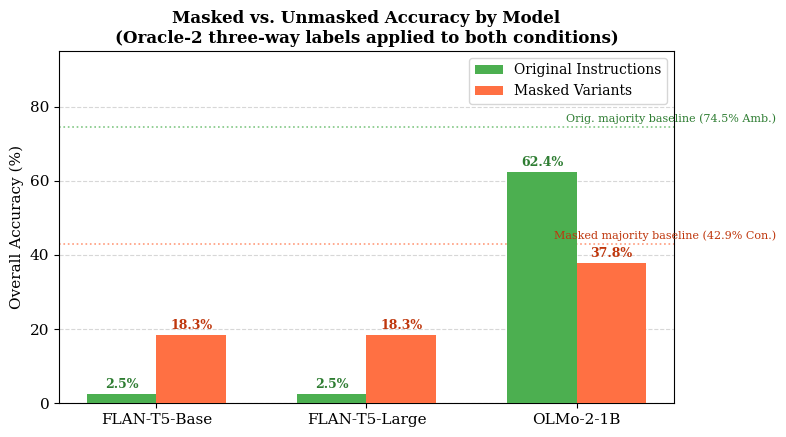

Saved: ../reports/plots2/supp_masked_vs_original_accuracy.pdf


In [17]:
# =============================================================================
# Supplementary Plot D: Masked vs. unmasked accuracy comparison per model
#
# What it shows:
#   Overall accuracy on ORIGINAL instructions vs. MASKED variants for each
#   model, as a grouped bar chart. Both sets are evaluated under Oracle-2
#   three-way labels.
#
# Why it exists:
#   Quantifies the accuracy degradation (or lack thereof) caused purely by
#   removing spatial information from the instructions while keeping the map
#   fixed.  Useful sanity-check: models that ignore instruction content should
#   show no degradation; models that reason spatially should degrade.
#   Note: overall accuracy on originals is low because ~75% of original
#   instructions are Ambiguous (making Ambiguous the de-facto majority class
#   in that subset), not because models perform well on masked variants.
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11

SAVE_DIR = "../reports/plots2"
os.makedirs(SAVE_DIR, exist_ok=True)

# Masked-variant results (Oracle-2 labels)
base_m  = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_BASE.parquet")
large_m = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_LARGE.parquet")
olmo_m  = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_OLMO.parquet")

# Original-instruction results (Oracle-2 labels applied to originals)
base_o  = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_ORIGINAL_BASE.parquet")
large_o = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_ORIGINAL_LARGE.parquet")
olmo_o  = pd.read_parquet("../reports/llm_audits/LLM_ANSWERABILITY_RESULTS_ORIGINAL_OLMO.parquet")

models = {
    'FLAN-T5-Base':  (base_o,  base_m),
    'FLAN-T5-Large': (large_o, large_m),
    'OLMo-2-1B':     (olmo_o,  olmo_m),
}

orig_accs   = [df_o['is_correct'].mean() * 100 for df_o, _ in models.values()]
masked_accs = [df_m['is_correct'].mean() * 100 for _, df_m in models.values()]

x = np.arange(len(models))
bar_w = 0.33

fig, ax = plt.subplots(figsize=(8, 4.5))

bars1 = ax.bar(x - bar_w / 2, orig_accs,   bar_w,
               color='#4CAF50', label='Original Instructions', zorder=3)
bars2 = ax.bar(x + bar_w / 2, masked_accs, bar_w,
               color='#FF7043', label='Masked Variants',       zorder=3)

for bar, val in zip(bars1, orig_accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#2E7D32')
for bar, val in zip(bars2, masked_accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#BF360C')

# Majority-class baselines differ between original and masked subsets
ax.axhline(y=74.5, color='#4CAF50', linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(len(models) - 0.05, 75.8, 'Orig. majority baseline (74.5% Amb.)',
        fontsize=8, color='#2E7D32', ha='right')
ax.axhline(y=42.9, color='#FF7043', linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(len(models) - 0.05, 44.2, 'Masked majority baseline (42.9% Con.)',
        fontsize=8, color='#BF360C', ha='right')

ax.set_xticks(x)
ax.set_xticklabels(list(models.keys()), fontsize=11)
ax.set_ylabel('Overall Accuracy (%)', fontsize=11)
ax.set_title(
    'Masked vs. Unmasked Accuracy by Model\n'
    '(Oracle-2 three-way labels applied to both conditions)',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0, 95)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, "supp_masked_vs_original_accuracy.pdf")
plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")